# Exercise 16.1 solution


## Exercise 16.1a solution


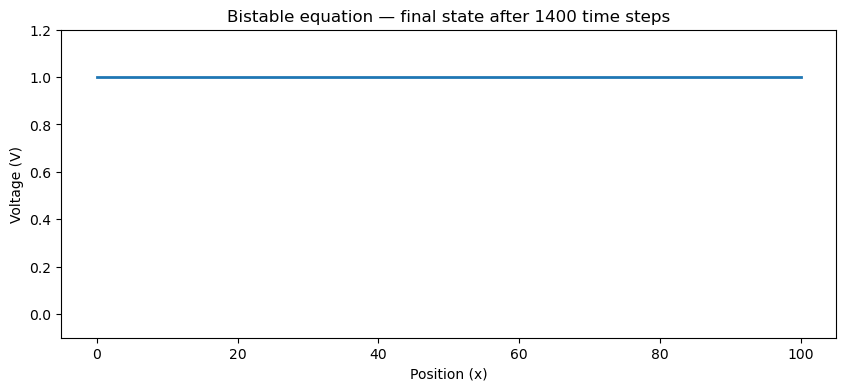

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
k = 2.0
A = 1.0
alpha = 0.1
L = 100

dx = 1
dt = 0.1
N = int(L / dx)
n_steps = 1400

# Initialize arrays
v = np.zeros(N + 1)
left = int(N / 10)
v[:left] = 0.3  # Apply the initial stimulus


def f(V):
    return A * V * (1 - V) * (V - alpha)


# Safely copy to preserve the previous time step
v_prev = np.copy(v)

# Simulation loop
for i in range(n_steps):
    # 1. Update internal nodes
    for j in range(1, N):
        I_ion = f(v_prev[j])
        diff = (k / dx**2) * (v_prev[j + 1] - 2 * v_prev[j] + v_prev[j - 1])
        v[j] = v_prev[j] + dt * diff + dt * I_ion

    # 2. Update boundaries
    v[0] = (
        v_prev[0] + dt * (k / dx**2) * 2 * (v_prev[1] - v_prev[0]) + dt * f(v_prev[0])
    )
    v[N] = (
        v_prev[N]
        + dt * (k / dx**2) * 2 * (v_prev[N - 1] - v_prev[N])
        + dt * f(v_prev[N])
    )

    # 3. Save the new state for the next step!
    v_prev = np.copy(v)

# Final plot
plt.figure(figsize=(10, 4))
plt.plot(v, color="C0", linewidth=2)
plt.xlabel("Position (x)")
plt.ylabel("Voltage (V)")
plt.title(f"Bistable equation — final state after {n_steps} time steps")
plt.ylim(-0.1, 1.2)
plt.show()

**Observation:** The travelling wave has a steep front moving to the right and leaves the cable at $V \approx 1$ behind it. The wave speed is approximately constant, and the wavefront shape does not change as it propagates (it is a _stable travelling wave_).


## Exercise 16.1b solution


In [2]:
from ipywidgets import interact, IntSlider

# Reset initial conditions
v = np.zeros(N + 1)
v[:left] = 0.3

# Introduce the appropriate arrays for slicing
I = np.arange(1, N)
Ip = I + 1
Im = I - 1

save_every = 10
snapshots = [v.copy()]

for i in range(n_steps):
    # Calculate reaction for ALL nodes
    I_ion = f(v)

    v_prev = np.copy(v)

    # Vectorized diffusion update
    v[I] = v_prev[I] + dt * (k / dx**2) * (v_prev[Ip] - 2 * v_prev[I] + v_prev[Im])

    # Update boundaries
    v[0] = v_prev[0] + dt * (k / dx**2) * 2 * (v_prev[1] - v_prev[0])
    v[N] = v_prev[N] + dt * (k / dx**2) * 2 * (v_prev[N - 1] - v_prev[N])

    # Add the reaction term simultaneously
    v = v + dt * I_ion

    if (i + 1) % save_every == 0:
        snapshots.append(v.copy())

snapshots = np.array(snapshots)
x = np.linspace(0, L, N + 1)


def plot_bistable(frame=0):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(x, snapshots[frame], color="C0", linewidth=2)
    ax.set_xlim(0, L)
    ax.set_ylim(-0.1, 1.2)
    ax.set_xlabel("Position (x)")
    ax.set_ylabel("Voltage (V)")
    t_ms = frame * save_every * dt
    ax.set_title(
        f"Bistable equation — t = {t_ms:.1f} ms (frame {frame}/{len(snapshots) - 1})"
    )
    plt.show()


interact(
    plot_bistable,
    frame=IntSlider(
        min=0, max=len(snapshots) - 1, step=1, value=0, description="Time frame"
    ),
)

interactive(children=(IntSlider(value=0, description='Time frame', max=140), Output()), _dom_classes=('widget-…

<function __main__.plot_bistable(frame=0)>

## Exercise 16.1c solution


In [ ]:
from ipywidgets import interact, FloatSlider, IntSlider


def run_bistable(alpha_w=0.1, k_w=2.0, A_w=1.0, frame=0):
    """Run the bistable equation and display a specific time frame."""
    dx_w = 1
    dt_w = 0.1
    L_w = 100
    N_w = int(L_w / dx_w)
    n_steps_w = 1400
    save_every_w = 10

    def f_w(V):
        return A_w * V * (1 - V) * (V - alpha_w)

    v = np.zeros(N_w + 1)
    v[: int(N_w / 10)] = 0.3

    I_arr = np.arange(1, N_w)
    Ip_arr = I_arr + 1
    Im_arr = I_arr - 1

    snaps = [v.copy()]
    for step in range(n_steps_w):
        I_ion_w = f_w(v)
        vp = np.copy(v)
        v[I_arr] = vp[I_arr] + dt_w * (k_w / dx_w**2) * (
            vp[Ip_arr] - 2 * vp[I_arr] + vp[Im_arr]
        )
        v[0] = vp[0] + dt_w * (k_w / dx_w**2) * 2 * (vp[1] - vp[0])
        v[N_w] = vp[N_w] + dt_w * (k_w / dx_w**2) * 2 * (vp[N_w - 1] - vp[N_w])
        v = v + dt_w * I_ion_w
        if (step + 1) % save_every_w == 0:
            snaps.append(v.copy())

    # Clamp frame index
    frame = min(frame, len(snaps) - 1)

    fig, ax = plt.subplots(figsize=(10, 4))
    x_arr = np.linspace(0, L_w, N_w + 1)
    ax.plot(x_arr, snaps[frame], color="C0", linewidth=2)
    ax.set_xlim(0, L_w)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel("Position (x)")
    ax.set_ylabel("Voltage (V)")
    r_val = k_w * dt_w / dx_w**2
    ax.set_title(
        f"α={alpha_w:.2f}, k={k_w:.1f}, A={A_w:.1f} | r={r_val:.2f} | "
        f"t = {frame * save_every_w * dt_w:.1f} ms"
    )
    plt.show()


interact(
    run_bistable,
    alpha_w=FloatSlider(min=0.05, max=0.50, step=0.01, value=0.10, description="α"),
    k_w=FloatSlider(min=0.5, max=5.0, step=0.1, value=2.0, description="k"),
    A_w=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description="A"),
    frame=IntSlider(min=0, max=140, step=1, value=70, description="Time frame"),
);

interactive(children=(FloatSlider(value=0.1, description='α', max=0.5, min=0.05, step=0.01), FloatSlider(value…

<function __main__.run_bistable(alpha_w=0.1, k_w=2.0, A_w=1.0, frame=0)>

Key observations:

1. **Increasing $\alpha$ toward 0.5:** The wave slows down and eventually fails to propagate (around $\alpha \approx 0.45$–$0.5$). This is because the "basin of attraction" for the $V=0$ equilibrium becomes very wide, meaning a larger perturbation is needed to push the voltage past the threshold, and diffusion alone cannot provide enough drive.

2. **Increasing $k$:** The wave travels faster because voltage diffuses more quickly between neighbouring grid points.

3. **Stability:** With $k > 2.5$ (giving $r = k \cdot 0.1 / 1^2 > 0.25$), the scheme is still stable. But if $k$ reaches 5.0 (giving $r = 0.5$), we are at the stability boundary. Going beyond (e.g. via modified $\Delta t$ or $\Delta x$) would produce oscillations.
